In [1]:
import pandas as pd
import numpy as np 

In [2]:
df =pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#AT = temperature
#V = vacum
#AP = pressure
#RH= humidity

#PE = produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
#split the data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [11]:
#data -> tensors
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [12]:
#tensorDataset & DataLoader
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [13]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [14]:
#define ANN Model (Deep Learning)
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output
        nn.Linear(6,1)
    )
    def forward(self,x):
        return self.model(x)

In [15]:
#Train the model
import torch.optim as optim

model=ANN()

crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [16]:
#evaluate -
epochs=50
training_loss=[]
validation_loss=[]
for epoch in range(epochs):
    model.train()
    running_loss=0.0  #total training loss for 1 epoch
    for xb,yb in train_loader:
        ##xb features of 1 batch
        #yb labels of 1 batch
        optimizer.zero_grad()
        outputs=model(xb) #predicted outputs
        loss=crietrion(outputs,yb) #compute loss
        loss.backward()#back propagation compute gradients
        optimizer.step()

        running_loss=loss.item() #loss is atensor => py float
    per_epoch_train_loss=running_loss/len(train_loader)
    training_loss.append(per_epoch_train_loss)


    #validation
    model.eval()
    running_val_loss=0.0
    
    with torch.no_grad(): #no gradient compute
         for xb,yb in test_loader:
             outputs=model(xb)
             loss=crietrion(outputs,yb)
             running_val_loss+= loss
    val_epoch_loss=running_val_loss/len(test_loader)
    validation_loss.append(val_epoch_loss)

    print(f"epoch {epoch+1}/{epochs}=> train loss ={per_epoch_train_loss} & val loss = {val_epoch_loss}")

epoch 1/50=> train loss =841.7935546875 & val loss = 203365.9375
epoch 2/50=> train loss =724.1477213541667 & val loss = 182219.703125
epoch 3/50=> train loss =490.95712890625 & val loss = 128211.3828125
epoch 4/50=> train loss =286.5489908854167 & val loss = 65663.7265625
epoch 5/50=> train loss =126.37308756510417 & val loss = 30903.25
epoch 6/50=> train loss =136.17181803385418 & val loss = 21127.43359375
epoch 7/50=> train loss =61.92481689453125 & val loss = 17198.15625
epoch 8/50=> train loss =56.372379557291666 & val loss = 13905.517578125
epoch 9/50=> train loss =68.83343912760417 & val loss = 10764.3779296875
epoch 10/50=> train loss =46.528971354166664 & val loss = 7856.13330078125
epoch 11/50=> train loss =8.321977233886718 & val loss = 5343.4482421875
epoch 12/50=> train loss =22.463533528645833 & val loss = 3348.98046875
epoch 13/50=> train loss =4.093518320719401 & val loss = 1954.011474609375
epoch 14/50=> train loss =2.403052012125651 & val loss = 1118.56005859375
epoch

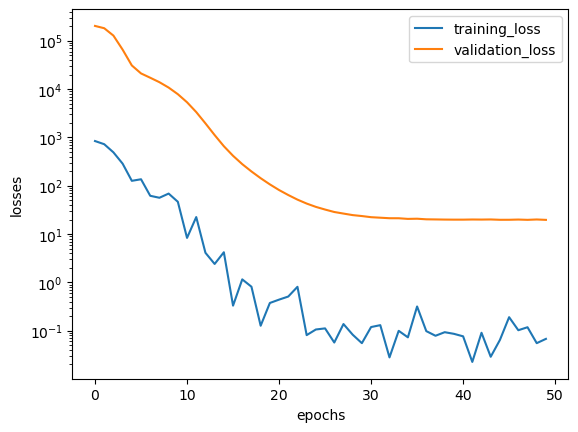

In [18]:
import matplotlib.pyplot as plt 
loss_df=pd.DataFrame(
    {
        "training_loss":training_loss,
        "validation_loss":validation_loss
    }
)
plt.plot(loss_df["training_loss"],label="training_loss")
plt.plot(loss_df["validation_loss"],label="validation_loss")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.yscale('log') 
plt.legend()